In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv('Stock Prices Data Set.csv')

In [16]:
df = df.reset_index(drop=True)

In [17]:
df.head(5) 

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [7]:
print(df.isnull().sum())

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64


In [8]:
df['open'] = df['open'].ffill()
df['high'] = df['high'].ffill()
df['low'] = df['low'].ffill()

In [9]:
print(df.isnull().sum())

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [11]:
print(df.dtypes)

symbol     object
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object


In [12]:
df['date'] = pd.to_datetime(df['date'])

In [13]:
df = df.drop_duplicates(subset=['symbol', 'date'])

In [18]:
df['daily_return']  = df.groupby('symbol')['close'].pct_change()
df['price_range']   = df['high'] - df['low']
df['price_change']  = df['close'] - df['open']
df['volatility']    = df.groupby('symbol')['daily_return'] \
                        .transform(lambda x: x.rolling(20).std())
df['MA_6']          = df.groupby('symbol')['close'] \
                        .transform(lambda x: x.rolling(6).mean())
df['MA_35']         = df.groupby('symbol')['close'] \
                        .transform(lambda x: x.rolling(35).mean())


In [19]:
df = df.dropna()

In [20]:
print(df.head())

      symbol       date      open      high       low     close    volume  \
16422    AAL 2014-02-21   35.7800   36.4500   35.7500   36.1700   7821334   
16423   AAPL 2014-02-21   76.1132   76.3671   74.9428   75.0356  69757247   
16424    AAP 2014-02-21  127.3100  128.4800  127.3100  127.9200    884094   
16425   ABBV 2014-02-21   51.8200   51.9700   51.0100   51.0400   5842724   
16426    ABC 2014-02-21   68.4200   69.1500   68.1600   68.4000   1113125   

       daily_return  price_range  price_change  volatility        MA_6  \
16422      0.014302       0.7000        0.3900    0.021418   35.027500   
16423     -0.011109       1.4243       -1.0776    0.021167   76.861350   
16424      0.002822       1.1700        0.6100    0.031505  126.968333   
16425     -0.015812       0.9600       -0.7800    0.016237   51.105000   
16426      0.000146       0.9900       -0.0200    0.013299   68.215000   

            MA_35  
16422   31.764000  
16423   76.206080  
16424  118.142857  
16425   49.7

In [21]:
df_agg = df.groupby('symbol').agg(
    avg_close       = ('close',         'mean'),
    avg_volume      = ('volume',        'mean'),
    avg_return      = ('daily_return',  'mean'),
    avg_volatility  = ('volatility',    'mean'),
    avg_price_range = ('price_range',   'mean'),
    avg_price_change= ('price_change',  'mean'),
    max_close       = ('close',         'max'),
    min_close       = ('close',         'min'),
    total_return    = ('daily_return',  'sum')
).reset_index()

In [23]:

print(df_agg.head)

<bound method NDFrame.head of     symbol   avg_close    avg_volume  avg_return  avg_volatility  \
0        A   48.772693  2.158012e+06    0.000290        0.013973   
1      AAL   42.801957  9.639933e+06    0.000638        0.021522   
2      AAP  144.072302  1.143474e+06   -0.000067        0.017159   
3     AAPL  118.258576  4.341895e+07    0.000924        0.013322   
4     ABBV   63.815324  8.445531e+06    0.000776        0.015093   
..     ...         ...           ...         ...             ...   
499    XYL   43.791475  1.151806e+06    0.000659        0.012127   
500    YUM   76.555683  3.198458e+06    0.000276        0.013783   
501    ZBH  111.139219  1.355378e+06    0.000337        0.012594   
502   ZION   32.772996  2.774697e+06    0.000688        0.015810   
503    ZTS   47.834972  3.423428e+06    0.001002        0.012987   

     avg_price_range  avg_price_change  max_close  min_close  total_return  
0           0.792638          0.009548      70.59    33.3700      0.281817  

In [24]:
features = ['avg_close', 'avg_volume', 'avg_return',
            'avg_volatility', 'avg_price_range',
            'avg_price_change', 'max_close',
            'min_close', 'total_return']

X = df_agg[features]

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=features)

In [25]:
print(X_scaled.head())
print(X_scaled.describe())

   avg_close  avg_volume  avg_return  avg_volatility  avg_price_range  \
0  -0.384287   -0.312340   -0.338758       -0.092749        -0.433231   
1  -0.445406    0.820178    0.411954        1.696769        -0.181855   
2   0.591241   -0.465908   -1.106894        0.662532         0.827400   
3   0.327001    5.933213    1.030312       -0.247077         0.186545   
4  -0.230304    0.639384    0.711044        0.172630        -0.143983   

   avg_price_change  max_close  min_close  total_return  
0         -0.155580  -0.358039  -0.381171     -0.350859  
1         -0.491089  -0.458869  -0.503439      0.454054  
2         -0.785125   0.524402   0.313345     -1.174453  
3          0.251525   0.361498   0.230732      1.117056  
4          0.642279  -0.170251  -0.183579      0.774737  
          avg_close    avg_volume    avg_return  avg_volatility  \
count  5.040000e+02  5.040000e+02  5.040000e+02    5.040000e+02   
mean  -5.639228e-17 -1.374562e-16 -2.819614e-17    9.516197e-17   
std    1.000

In [26]:
wcss    = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters  = k,
        init        = 'k-means++',
        max_iter    = 300,
        random_state= 42
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    print(f"K={k}  WCSS: {kmeans.inertia_:.2f}")

K=1  WCSS: 4536.00
K=2  WCSS: 3826.91
K=3  WCSS: 2664.36
K=4  WCSS: 2370.03
K=5  WCSS: 2060.63
K=6  WCSS: 1910.48
K=7  WCSS: 1743.72
K=8  WCSS: 1505.14
K=9  WCSS: 1425.12
K=10  WCSS: 1370.83


C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

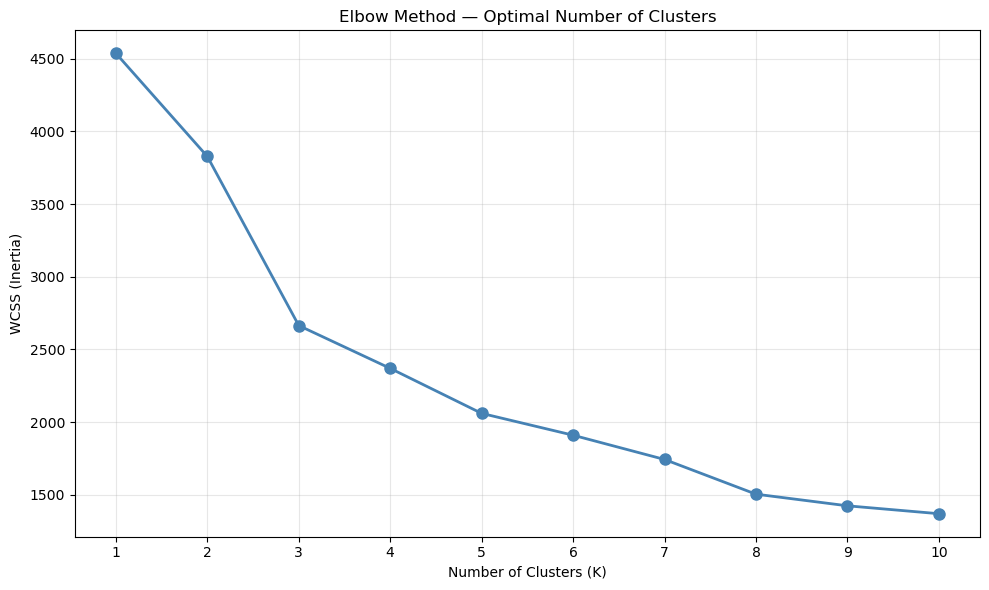

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', color='steelblue',
         linewidth=2, markersize=8)
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

K=2  Silhouette Score: 0.8758
K=3  Silhouette Score: 0.2478
K=4  Silhouette Score: 0.2101
K=5  Silhouette Score: 0.2601
K=6  Silhouette Score: 0.2594
K=7  Silhouette Score: 0.2000


C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


K=8  Silhouette Score: 0.2080
K=9  Silhouette Score: 0.2014
K=10  Silhouette Score: 0.1938


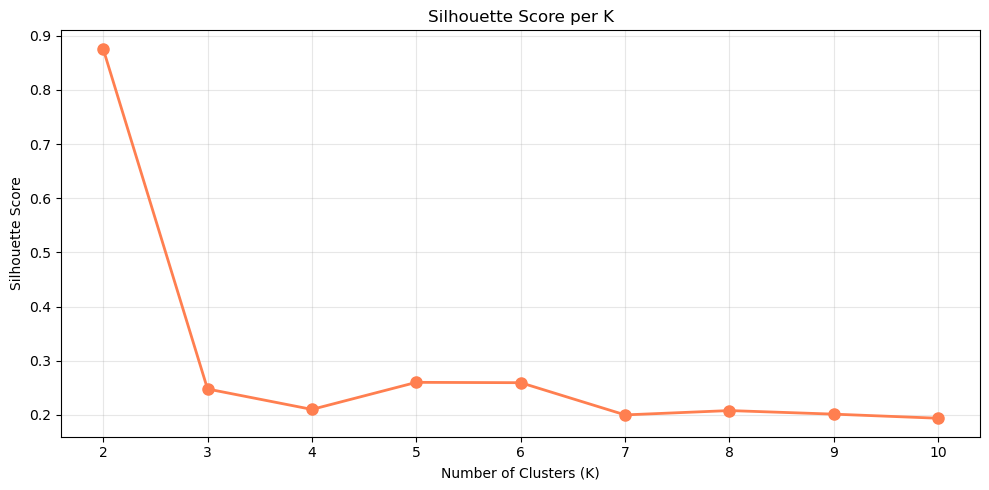

In [28]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}  Silhouette Score: {score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), silhouette_scores,
         marker='o', color='coral', linewidth=2, markersize=8)
plt.title('Silhouette Score per K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
optimal_k = 3

kmeans = KMeans(
    n_clusters  = optimal_k,
    init        = 'k-means++',
    max_iter    = 300,
    random_state= 42
)

kmeans.fit(X_scaled)

df_agg['Cluster'] = kmeans.labels_

print(df_agg['Cluster'].value_counts())
print(df_agg.head())

Cluster
1    295
0    202
2      7
Name: count, dtype: int64
  symbol   avg_close    avg_volume  avg_return  avg_volatility  \
0      A   48.772693  2.158012e+06    0.000290        0.013973   
1    AAL   42.801957  9.639933e+06    0.000638        0.021522   
2    AAP  144.072302  1.143474e+06   -0.000067        0.017159   
3   AAPL  118.258576  4.341895e+07    0.000924        0.013322   
4   ABBV   63.815324  8.445531e+06    0.000776        0.015093   

   avg_price_range  avg_price_change  max_close  min_close  total_return  \
0         0.792638          0.009548      70.59    33.3700      0.281817   
1         1.246386         -0.005487      55.76    25.2700      0.620526   
2         3.068150         -0.018664     200.38    79.3800     -0.064753   
3         1.911369          0.027791     176.42    73.9071      0.899518   
4         1.314746          0.045302      98.21    46.4600      0.755470   

   Cluster  
0        0  
1        0  
2        0  
3        1  
4        1  


C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [30]:

cluster_summary = df_agg.groupby('Cluster')[features].mean()
print("Cluster Summary:\n", cluster_summary)

print("\nStocks per Cluster:")
print(df_agg['Cluster'].value_counts().sort_index())

for cluster in range(optimal_k):
    stocks = df_agg[df_agg['Cluster'] == cluster]['symbol'].tolist()
    print(f"\nCluster {cluster}: {stocks}")

Cluster Summary:
           avg_close    avg_volume  avg_return  avg_volatility  \
Cluster                                                         
0         57.591247  5.879851e+06    0.000074        0.016080   
1         91.193534  3.147900e+06    0.000701        0.013166   
2        709.516206  1.608627e+06    0.000493        0.015398   

         avg_price_range  avg_price_change    max_close   min_close  \
Cluster                                                               
0               1.174076         -0.006974    78.309059   38.835604   
1               1.584014          0.035896   131.671542   62.588837   
2              12.739025         -0.122079  1065.255714  462.401429   

         total_return  
Cluster                
0            0.083954  
1            0.665026  
2            0.472294  

Stocks per Cluster:
Cluster
0    202
1    295
2      7
Name: count, dtype: int64

Cluster 0: ['A', 'AAL', 'AAP', 'ADM', 'ADS', 'AES', 'AGN', 'AIG', 'AKAM', 'ALXN', 'AMG', 'APA', '

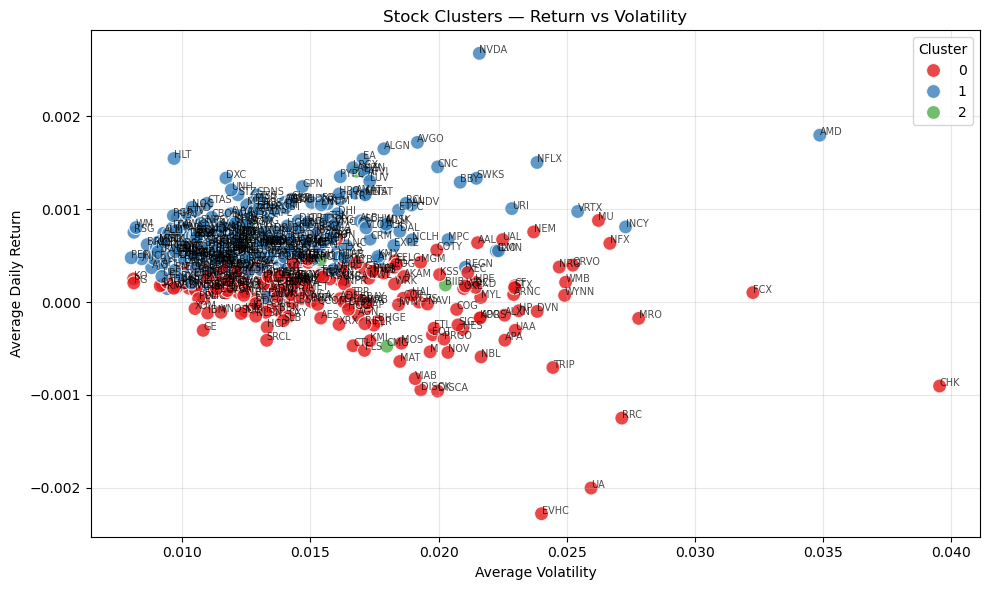

In [31]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_agg, x='avg_volatility', y='avg_return',
                hue='Cluster', palette='Set1',
                s=100, alpha=0.8)
for _, row in df_agg.iterrows():
    plt.annotate(row['symbol'],
                 (row['avg_volatility'], row['avg_return']),
                 fontsize=7, alpha=0.7)

plt.title('Stock Clusters — Return vs Volatility')
plt.xlabel('Average Volatility')
plt.ylabel('Average Daily Return')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()